In [3]:
import os
from  pathlib import Path
from google.colab import drive
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Dropout, Flatten, BatchNormalization as Normalization,GlobalAveragePooling2D
from tensorflow.keras.optimizers import SGD
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

In [4]:

drive.mount('/content/drive')

Mounted at /content/drive


In [57]:
os.listdir('/content/drive/MyDrive/AI-DEEP learning/CNN Cats and Dogs/Cats_Dogs-20260722T141144Z-1-001/Cats_Dogs')

['dogs', 'cats']

In [10]:
DATASET_PATH= Path('/content/drive/MyDrive/AI-DEEP learning/CNN Cats and Dogs/Cats_Dogs-20260722T141144Z-1-001/Cats_Dogs')

In [59]:
print(DATASET_PATH.exists())
print(f"DATASET_PATH: {DATASET_PATH}")

True
DATASET_PATH: /content/drive/MyDrive/AI-DEEP learning/CNN Cats and Dogs/Cats_Dogs-20260722T141144Z-1-001/Cats_Dogs


#Create two ImageDataGenerator objects.

In [60]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    horizontal_flip=True,
    zoom_range=0.2
)




In [8]:
validation_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [62]:
train_datagen

In [63]:
dir(train_datagen)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_api_export_path',
 '_api_export_symbol_id',
 '_validation_split',
 'apply_transform',
 'brightness_range',
 'channel_axis',
 'channel_shift_range',
 'col_axis',
 'cval',
 'data_format',
 'dtype',
 'featurewise_center',
 'featurewise_std_normalization',
 'fill_mode',
 'fit',
 'flow',
 'flow_from_dataframe',
 'flow_from_directory',
 'get_random_transform',
 'height_shift_range',
 'horizontal_flip',
 'interpolation_order',
 'mean',
 'preprocessing_function',
 'random_transform',
 'rescale',
 'rotation_range',
 'row_axis',
 'samplewise_center',
 'samplewise_std_normalization',
 'shear_range',
 'standardize'

#Then create the generators: one for traning , one for validation

In [64]:
train_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary",
    subset="training",
    shuffle=True
)

Found 1600 images belonging to 2 classes.


In [11]:
validation_generator = validation_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(224,224),
    batch_size=32,
    class_mode="binary",
    subset="validation",
    shuffle=False
)

Found 400 images belonging to 2 classes.


In [66]:
print(train_generator.class_indices)
print(validation_generator.class_indices)

{'cats': 0, 'dogs': 1}
{'cats': 0, 'dogs': 1}


In [67]:
print("Training Images:", train_generator.samples)
print("Validation Images:", validation_generator.samples)

Training Images: 1600
Validation Images: 400


In [68]:
import numpy as np

labels = train_generator.classes

print(np.bincount(labels))

[800 800]


In [69]:
import numpy as np

labels = validation_generator.classes

print(np.bincount(labels))

[200 200]


## 📌 Training Generator vs Validation Generator

Although both generators read images from the same dataset, **their purposes are different**, so their configurations should also be different.

| Configuration | Training Generator | Validation Generator | Reason |
|---------------|-------------------|----------------------|--------|
| `rescale=1./255` | ✅ Yes | ✅ Yes | Normalize pixel values to the range [0,1]. |
| `rotation_range` | ✅ Yes | ❌ No | Helps the model learn from rotated images. Validation images should remain unchanged. |
| `horizontal_flip` | ✅ Yes | ❌ No | Improves robustness to left-right variations during training. |
| `zoom_range` | ✅ Yes | ❌ No | Makes the model robust to objects appearing at different scales. |
| `brightness_range` | ✅ Optional | ❌ No | Simulates different lighting conditions only during training. |
| `shear_range` | ✅ Optional | ❌ No | Introduces geometric variations during training. |
| `shuffle` | ✅ Yes | Usually ❌ No | Training benefits from random batches. Validation should remain consistent for fair evaluation. |

Validation: We don't need randomness.

We simply evaluate the same validation set each epoch.

---



In [70]:
dir(train_generator)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__iter__',
 '__le__',
 '__len__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__next__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_api_export_path',
 '_api_export_symbol_id',
 '_filepaths',
 '_flow_index',
 '_get_batches_of_transformed_samples',
 '_max_queue_size',
 '_set_index_array',
 '_use_multiprocessing',
 '_warn_if_super_not_called',
 '_workers',
 'allowed_class_modes',
 'batch_index',
 'batch_size',
 'class_indices',
 'class_mode',
 'classes',
 'color_mode',
 'data_format',
 'directory',
 'dtype',
 'filenames',
 'filepaths',
 'image_data_generator',
 'image_shape',
 'index_array',
 'index_generator',
 'interpolation',
 'keep_aspect_ratio',
 'labels',
 'lock',
 'max_queue_

In [71]:
train_generator.class_indices

{'cats': 0, 'dogs': 1}

In [72]:
train_generator.color_mode

'rgb'

In [73]:
train_generator.image_shape

(224, 224, 3)

In [74]:
print(len(train_generator))

50


In [75]:
vars(train_datagen)

{'featurewise_center': False,
 'samplewise_center': False,
 'featurewise_std_normalization': False,
 'samplewise_std_normalization': False,
 'zca_whitening': False,
 'zca_epsilon': 1e-06,
 'rotation_range': 20,
 'width_shift_range': 0.0,
 'height_shift_range': 0.0,
 'shear_range': 0.0,
 'zoom_range': [0.8, 1.2],
 'channel_shift_range': 0.0,
 'fill_mode': 'nearest',
 'cval': 0.0,
 'horizontal_flip': True,
 'vertical_flip': False,
 'rescale': 0.00392156862745098,
 'preprocessing_function': None,
 'dtype': 'float32',
 'interpolation_order': 1,
 'data_format': 'channels_last',
 'channel_axis': 3,
 'row_axis': 1,
 'col_axis': 2,
 '_validation_split': 0.2,
 'mean': None,
 'std': None,
 'zca_whitening_matrix': None,
 'brightness_range': None}

1600 images
──────────── = 50 batches
32 images/batch

In [76]:
images, labels = next(train_generator)

In [77]:
print(f"image shape:{images.shape} label shape:{labels.shape}")


image shape:(32, 224, 224, 3) label shape:(32,)


In [78]:
labels[:5]

array([0., 1., 1., 0., 1.], dtype=float32)

(32, 224, 224, 3)
 │    │    │    │
 │    │    │    └── Channels (RGB)
 │    │    └────── Width
 │    └─────────── Height
 └──────────────── Number of Images (Batch Size)

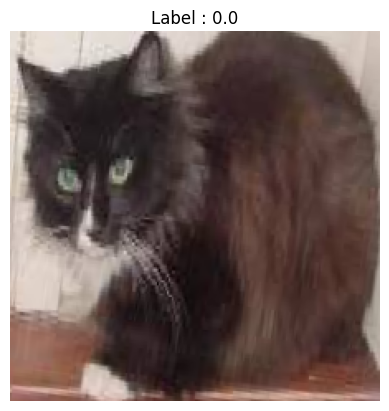

In [79]:
import matplotlib.pyplot as plt

plt.imshow(images[0])
plt.title(f"Label : {labels[0]}")
plt.axis("off")
plt.show()

In [80]:
print(type(images))
print(type(labels))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


## 📌 What does ImageDataGenerator return?

When we execute:

```python
images, labels = next(train_generator)
```

the `ImageDataGenerator` reads one batch of images from the dataset and returns **two NumPy arrays**.

### Data Flow

```text
Image Files (.jpg)

        │
        ▼

ImageDataGenerator

        │
        ▼

Image Preprocessing
• Resize Images
• Rescale Pixel Values
• (Optional) Data Augmentation

        │
        ▼

NumPy Arrays

        │
        ├── images → Shape : (32, 224, 224, 3)
        │
        └── labels → Shape : (32,)

        │
        ▼

model.fit()

        │
        ▼

TensorFlow internally converts NumPy arrays into Tensors

        │
        ▼

CNN
```

---

### Understanding `images.shape`

```python
images.shape
```

Output

```python
(32, 224, 224, 3)
```

Meaning

| Dimension | Meaning |
|-----------|---------|
| 32 | Number of images in one batch (Batch Size) |
| 224 | Image Height |
| 224 | Image Width |
| 3 | RGB Channels |

---

### Understanding `labels.shape`

```python
labels.shape
```

Output

```python
(32,)
```

Meaning

- One label for each image in the batch.
- Since this is a binary classification problem (`cats` vs `dogs`), labels are stored as:

```text
Cat  → 0
Dog  → 1
```

Example

```python
[0., 1., 0., 1., 1., 0., ...]
```

---

### Important Observation

`ImageDataGenerator` **does not return TensorFlow tensors**.

It returns **NumPy arrays**.

During

```python
model.fit(train_generator)
```

TensorFlow automatically converts these NumPy arrays into tensors before feeding them into the CNN.

---

### Learning Summary

```text
Image Files (.jpg)

        ↓

ImageDataGenerator

        ↓

NumPy Arrays

        ↓

TensorFlow

        ↓

Tensor

        ↓

CNN
```

> **Note:** `ImageDataGenerator` is part of TensorFlow's **legacy preprocessing API**, which is why it produces NumPy arrays. In modern TensorFlow pipelines, `tf.data.Dataset` returns TensorFlow tensors directly.

Momentum is an optimization technique used with SGD to speed up training.

Without Momentum:
• The optimizer updates weights using only the current gradient.
• Training can be slow and may oscillate while approaching the minimum.

With Momentum:
• The optimizer remembers a fraction of the previous update and combines it with the current update.
• This helps move faster in the correct direction.
• Reduces oscillations.
• Often leads to faster convergence and better training stability.

Common values:
• momentum = 0.9 (most commonly used)
• momentum = 0.95
• momentum = 0.99

In [81]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    BatchNormalization,
    MaxPooling2D,
    Dropout,
    Flatten,
    Dense
)
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import SGD


def CNN_MODEL(l2_reg=0.001,
              dropout=0.20,
              learning_rate=0.0001,
              momentum=0.9):

    model = Sequential([

        # ==========================
        # Input Layer
        # ==========================
        Input(shape=(224,224,3)),

        # ==========================
        # Block 1
        # Learns edges and textures
        # ==========================
        Conv2D(32, (3,3),
               padding='same',
               activation='relu',
               kernel_regularizer=regularizers.l2(l2_reg)),

        BatchNormalization(),

        Conv2D(32, (3,3),
               padding='same',
               activation='relu',
               kernel_regularizer=regularizers.l2(l2_reg)),

        BatchNormalization(),

        MaxPooling2D((2,2)),
        Dropout(dropout),

        # ==========================
        # Block 2
        # Learns eyes, ears, nose
        # ==========================
        Conv2D(64,(3,3),
               padding='same',
               activation='relu',
               kernel_regularizer=regularizers.l2(l2_reg)),

        BatchNormalization(),

        Conv2D(64,(3,3),
               padding='same',
               activation='relu',
               kernel_regularizer=regularizers.l2(l2_reg)),

        BatchNormalization(),

        MaxPooling2D((2,2)),
        Dropout(dropout),

        # ==========================
        # Block 3
        # Learns face, body shape
        # ==========================
        Conv2D(128,(3,3),
               padding='same',
               activation='relu',
               kernel_regularizer=regularizers.l2(l2_reg)),

        BatchNormalization(),

        Conv2D(128,(3,3),
               padding='same',
               activation='relu',
               kernel_regularizer=regularizers.l2(l2_reg)),

        BatchNormalization(),

        MaxPooling2D((2,2)),
        Dropout(dropout),

        # ==========================
        # Classification Head
        # ==========================
        GlobalAveragePooling2D(),

        Dense(256,
              activation='relu',
              kernel_regularizer=regularizers.l2(l2_reg)),

        Dropout(0.5),

        Dense(1, activation='sigmoid')
    ])


    optimizer = SGD(
        learning_rate=learning_rate,
        momentum=momentum
    )

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [82]:
model = CNN_MODEL(
    l2_reg=0.001,
    dropout=0.20,
    learning_rate=0.0001,
    momentum=0.9
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 322,081 (1.23 MB)

 Trainable params: 321,185 (1.23 MB)

 Non-trainable params: 896 (3.50 KB)

Define the Save Path

In [83]:
MODEL_DIR = Path("/content/drive/MyDrive/AI-DEEP learning/CNN Cats and Dogs/saved_models")

MODEL_DIR.mkdir(parents=True, exist_ok=True)

##ModelCheckpoint

In [84]:
checkpoint = ModelCheckpoint(
    filepath=MODEL_DIR / "best_cats_dogs_model.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min",
    verbose=1
)

#EarlyStopping

In [85]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

#Reduce Learning Rate

What is inside train_generator?

Not just images.It already contains

Images-->Labels-->Batch Information-->Shuffle Information-->Rescaling-->Augmentation

In [86]:
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)
print("GPUs Available:", tf.config.list_physical_devices('GPU'))
print("CPUs Available:", tf.config.list_physical_devices('CPU'))

TensorFlow Version: 2.20.0
GPUs Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
CPUs Available: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [87]:
history=model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=50,
    callbacks=[
        early_stop,
        checkpoint
    ]
)

Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 549ms/step - accuracy: 0.5042 - loss: 1.3198
Epoch 1: val_loss improved from None to 1.22381, saving model to /content/drive/MyDrive/AI-DEEP learning/CNN Cats and Dogs/saved_models/best_cats_dogs_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/AI-DEEP learning/CNN Cats and Dogs/saved_models/best_cats_dogs_model.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 42s 635ms/step - accuracy: 0.5081 - loss: 1.3013 - val_accuracy: 0.5000 - val_loss: 1.2238
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 551ms/step - accuracy: 0.5251 - loss: 1.2559
Epoch 2: val_loss did not improve from 1.22381
50/50 ━━━━━━━━━━━━━━━━━━━━ 29s 587ms/step - accuracy: 0.5444 - loss: 1.2494 - val_accuracy: 0.5000 - val_loss: 1.2291
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 557ms/step - accuracy: 0.5904 - loss: 1.2131
Epoch 3: val_loss did not improve from 1.22381
50/50 ━━━━━━━━━━━━━━━━━━━━ 30s 594ms/step - accuracy: 0.5744 - loss: 1.2290 - val_accuracy: 0.5000 - val_loss: 1.233

What happens internally? Suppose the CNN asks"Give me the next batch."

TensorFlow internally does something like images, labels = next(train_generator)

which returns images.shape (32,224,224,3) labels.shape:(32,)

The CNN immediately trains on that batch. Then it asks again.next(train_generator)

Next batch. Again. next(train_generator)

Next batch.

This continues until all batches in one epoch are processed.

In [5]:
from tensorflow.keras.models import load_model

model = load_model(
    "/content/drive/MyDrive/AI-DEEP learning/CNN Cats and Dogs/saved_models/best_cats_dogs_model.keras"
)

In [12]:
loss, accuracy = model.evaluate(validation_generator)

print("Validation Loss :", loss)
print("Validation Accuracy :", accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 83s 6s/step - accuracy: 0.5000 - loss: 1.2238
Validation Loss : 1.2238131761550903
Validation Accuracy : 0.5


In [15]:
validation_generator.reset()

predictions = model.predict(validation_generator)

13/13 ━━━━━━━━━━━━━━━━━━━━ 45s 3s/step


In [16]:
predicted_classes = (predictions >= 0.5).astype(int).flatten()

In [17]:
actual_classes = validation_generator.classes

In [18]:
for i in range(20):

    print(
        f"Image {i+1}",
        f"Actual={actual_classes[i]}",
        f"Predicted={predicted_classes[i]}",
        f"Probability={predictions[i][0]:.4f}"
    )

Image 1 Actual=0 Predicted=0 Probability=0.4664
Image 2 Actual=0 Predicted=0 Probability=0.4715
Image 3 Actual=0 Predicted=0 Probability=0.4699
Image 4 Actual=0 Predicted=0 Probability=0.4661
Image 5 Actual=0 Predicted=0 Probability=0.4681
Image 6 Actual=0 Predicted=0 Probability=0.4690
Image 7 Actual=0 Predicted=0 Probability=0.4701
Image 8 Actual=0 Predicted=0 Probability=0.4706
Image 9 Actual=0 Predicted=0 Probability=0.4676
Image 10 Actual=0 Predicted=0 Probability=0.4688
Image 11 Actual=0 Predicted=0 Probability=0.4716
Image 12 Actual=0 Predicted=0 Probability=0.4705
Image 13 Actual=0 Predicted=0 Probability=0.4683
Image 14 Actual=0 Predicted=0 Probability=0.4702
Image 15 Actual=0 Predicted=0 Probability=0.4694
Image 16 Actual=0 Predicted=0 Probability=0.4700
Image 17 Actual=0 Predicted=0 Probability=0.4714
Image 18 Actual=0 Predicted=0 Probability=0.4673
Image 19 Actual=0 Predicted=0 Probability=0.4703
Image 20 Actual=0 Predicted=0 Probability=0.4710
